# Ejercicio 4 — Análisis exploratorio con DuckDB

Las consultas están en `sql/04_eda.sql` y leen los Parquet a través de las vistas de `sql/00_vistas.sql` (`trips_clean` = viajes sin los registros inválidos del Ejercicio 3).
DuckDB hace toda la agregación; a pandas solo llegan resultados de pocas filas para graficar.
Las preguntas, la interpretación y los hallazgos están en `docs/04_eda.md`.

In [1]:
import sys
sys.path.insert(0, "../scripts")
import matplotlib.pyplot as plt
import pandas as pd
from sqlrun import conectar, cargar_consultas

pd.set_option("display.max_columns", 30)
pd.set_option("display.width", 200)
con = conectar()          # DuckDB en memoria + vistas de sql/00_vistas.sql (sobre Parquet)
from pathlib import Path
import numpy as np

q = cargar_consultas("sql/04_eda.sql")
FIG = Path("docs/figuras"); FIG.mkdir(parents=True, exist_ok=True)
COLOR = {"yellow": "#d4a017", "green": "#2e8b57"}

def run(nombre):
    return con.sql(q[nombre].sql).df()

def guardar(fig, nombre):
    fig.savefig(FIG / f"{nombre}.png", dpi=110, bbox_inches="tight")

## Comportamiento temporal
### P1. ¿Cómo evoluciona el volumen de viajes por mes?

,mes,taxi_type,viajes,viajes_por_dia,ingreso_prom,ingreso_total_musd
0,2026-01-01,yellow,3560724,114862.0,29.61,105.44
1,2026-01-01,green,38771,1251.0,24.26,0.94
2,2026-02-01,yellow,3250299,116082.0,30.40,98.80
3,2026-02-01,green,35788,1278.0,24.35,0.87
4,2026-03-01,yellow,3810964,122934.0,30.21,115.13
5,2026-03-01,green,42506,1371.0,24.88,1.06
6,2026-04-01,yellow,3723482,124116.0,30.05,111.88
7,2026-04-01,green,42370,1412.0,25.33,1.07
8,2026-05-01,yellow,3963589,127858.0,30.50,120.89
9,2026-05-01,green,43103,1390.0,25.78,1.11


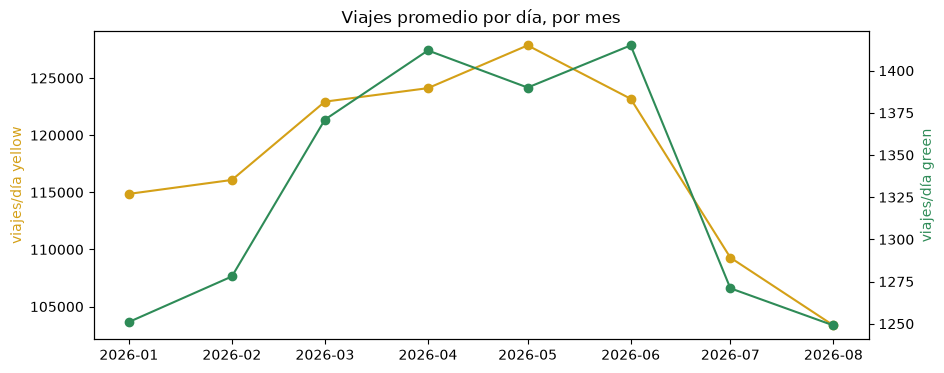

In [2]:
df = run("viajes_por_mes"); display(df)
fig, ax1 = plt.subplots(figsize=(10, 4))
for taxi, ax in (("yellow", ax1), ("green", ax1.twinx())):
    d = df[df.taxi_type == taxi]
    ax.plot(d.mes, d.viajes_por_dia, marker="o", color=COLOR[taxi], label=taxi)
    ax.set_ylabel(f"viajes/día {taxi}", color=COLOR[taxi])
ax1.set_title("Viajes promedio por día, por mes")
guardar(fig, "04_viajes_por_mes")

### P2. ¿Qué días y horas concentran la demanda?

In [3]:
run("demanda_por_dia_semana")

,taxi_type,dia_iso,dia,viajes_por_dia,distancia_prom
0,yellow,1,Monday,97189.0,3.75
1,yellow,2,Tuesday,114679.0,3.39
2,yellow,3,Wednesday,122219.0,3.35
3,yellow,4,Thursday,129080.0,3.38
4,yellow,5,Friday,122147.0,3.45
5,yellow,6,Saturday,130155.0,3.40
6,yellow,7,Sunday,108339.0,3.92
7,green,1,Monday,1318.0,3.30
8,green,2,Tuesday,1438.0,3.32
9,green,3,Wednesday,1492.0,3.32


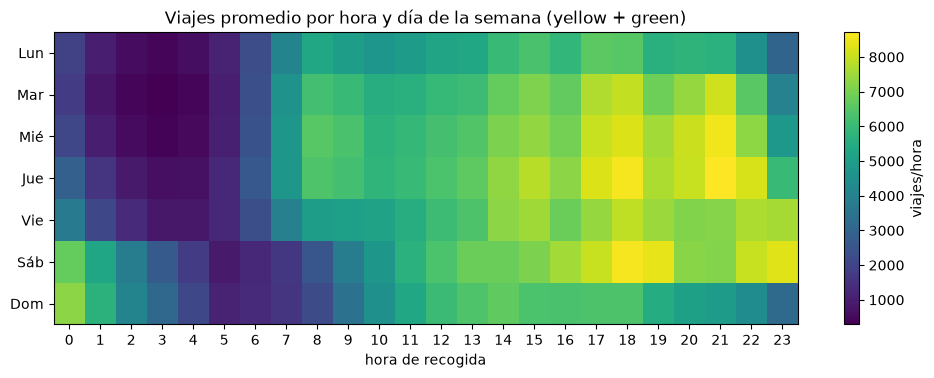

In [4]:
df = run("demanda_hora_dia")
m = df.pivot(index="dia_iso", columns="hora", values="viajes_promedio")
fig, ax = plt.subplots(figsize=(12, 3.8))
im = ax.imshow(m, aspect="auto", cmap="viridis")
ax.set_yticks(range(7), ["Lun", "Mar", "Mié", "Jue", "Vie", "Sáb", "Dom"])
ax.set_xticks(range(24)); ax.set_xlabel("hora de recogida")
ax.set_title("Viajes promedio por hora y día de la semana (yellow + green)")
fig.colorbar(im, ax=ax, label="viajes/hora")
guardar(fig, "04_heatmap_hora_dia")

### P3. ¿Cómo cambia la velocidad a lo largo del día?

,hora,taxi_type,viajes,duracion_mediana_min,distancia_mediana_mi,velocidad_mediana_mph
0,0,yellow,904836,13.8,2.60,11.8
1,1,yellow,600890,13.1,2.58,12.3
2,2,yellow,399732,12.7,2.64,12.9
3,3,yellow,287070,12.7,2.87,13.8
4,4,yellow,234532,13.7,3.53,15.4
5,5,yellow,259501,13.7,3.77,16.0
6,6,yellow,488990,12.9,2.96,13.8
7,7,yellow,854574,13.1,2.30,11.1
8,8,yellow,1147445,14.1,2.00,9.3
9,9,yellow,1201498,14.2,1.85,8.9


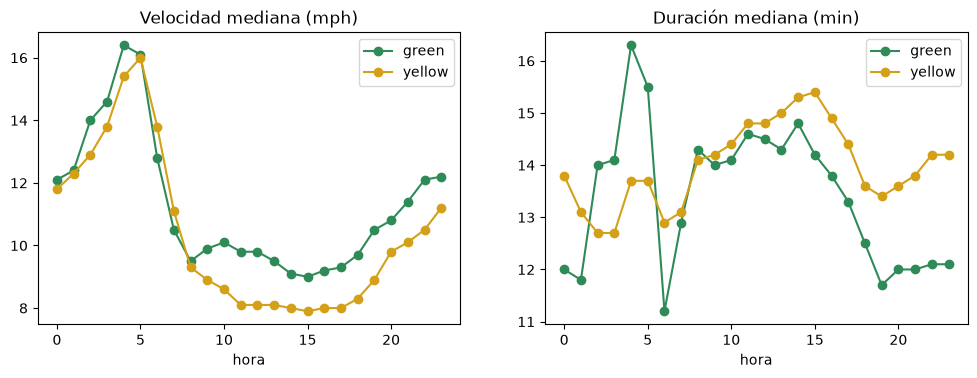

In [5]:
df = run("velocidad_por_hora")
fig, axes = plt.subplots(1, 2, figsize=(12, 3.8))
for taxi, d in df.groupby("taxi_type"):
    axes[0].plot(d.hora, d.velocidad_mediana_mph, marker="o", color=COLOR[taxi], label=taxi)
    axes[1].plot(d.hora, d.duracion_mediana_min, marker="o", color=COLOR[taxi], label=taxi)
axes[0].set_title("Velocidad mediana (mph)"); axes[1].set_title("Duración mediana (min)")
for ax in axes: ax.set_xlabel("hora"); ax.legend()
guardar(fig, "04_velocidad_por_hora")
df[df.taxi_type == "yellow"]

## Características de los viajes
### P4. Perfil y distribución de un viaje yellow vs green

In [6]:
run("comparacion_tipos")

,taxi_type,viajes,distancia_prom,distancia_mediana,duracion_mediana,pasajeros_prom,tarifa_mediana,total_mediano,tarifa_por_milla_mediana,pct_misma_zona
0,yellow,28596404,3.51,1.92,14.1,1.25,15.6,23.58,7.55,3.8
1,green,323096,3.35,2.14,13.3,1.30,13.5,20.52,6.68,8.9


In [7]:
run("percentiles_distancia_duracion")

,taxi_type,variable,p05,p25,p50,p75,p95,p99
0,yellow,duration_min,4.02,8.62,14.10,22.25,44.05,71.30
1,green,duration_min,4.13,8.68,13.32,20.62,44.08,75.03
2,yellow,total_amount,12.40,17.45,23.58,34.42,77.18,104.96
3,green,total_amount,9.70,15.12,20.52,29.70,56.64,95.20
4,yellow,trip_distance,0.50,1.10,1.92,3.93,12.51,19.54
5,green,trip_distance,0.63,1.33,2.14,3.77,10.65,17.75


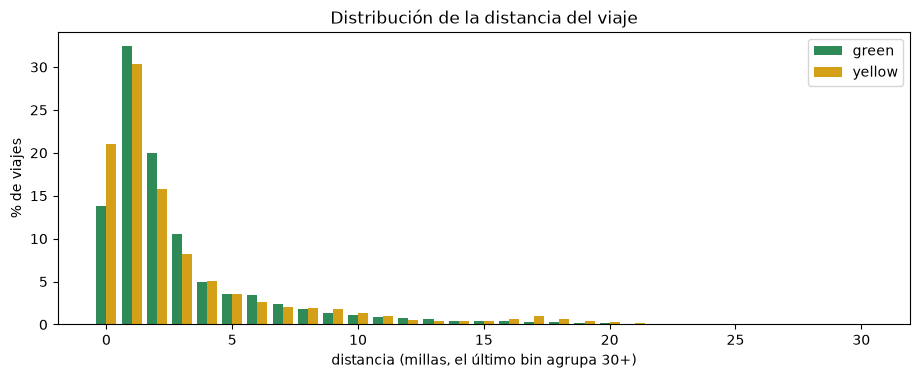

In [8]:
df = run("histograma_distancia")
fig, ax = plt.subplots(figsize=(11, 3.8))
for i, (taxi, d) in enumerate(df.groupby("taxi_type")):
    ax.bar(d.milla + (i - 0.5) * 0.4, d.pct, width=0.4, color=COLOR[taxi], label=taxi)
ax.set_xlabel("distancia (millas, el último bin agrupa 30+)"); ax.set_ylabel("% de viajes")
ax.set_title("Distribución de la distancia del viaje"); ax.legend()
guardar(fig, "04_histograma_distancia")

In [9]:
run("pasajeros")

,taxi_type,pasajeros,viajes,pct
0,yellow,0,87520,0.31
1,yellow,1,17732553,62.01
2,yellow,2,2652016,9.27
3,yellow,3,598042,2.09
4,yellow,4,392945,1.37
5,yellow,5,55563,0.19
6,yellow,6,33078,0.12
7,yellow,7,2,0.00
8,yellow,8,7,0.00
9,yellow,9,1,0.00


### P5. ¿Dónde comienzan los viajes?

,taxi_type,borough_origen,viajes,pct
0,yellow,Manhattan,24799696,86.72
1,yellow,Queens,2520729,8.81
2,yellow,Brooklyn,1017665,3.56
3,yellow,Bronx,218885,0.77
4,yellow,Unknown,29456,0.10
5,yellow,N/A,6377,0.02
6,yellow,Staten Island,2672,0.01
7,yellow,EWR,924,0.00
8,green,Manhattan,192142,59.47
9,green,Queens,71208,22.04


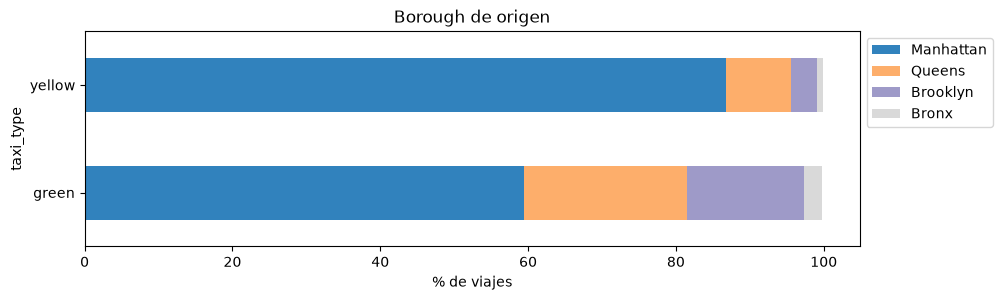

In [10]:
df = run("zonas_origen_borough")
p = df.pivot(index="taxi_type", columns="borough_origen", values="pct").fillna(0)
p = p[[c for c in ["Manhattan", "Queens", "Brooklyn", "Bronx"] if c in p] ]
ax = p.plot.barh(stacked=True, figsize=(10, 2.8), colormap="tab20c")
ax.set_xlabel("% de viajes"); ax.set_title("Borough de origen"); ax.legend(bbox_to_anchor=(1, 1))
guardar(ax.figure, "04_borough_origen")
df

In [11]:
run("top_zonas_origen")

,taxi_type,borough,zone,viajes,pct
0,yellow,Manhattan,Upper East Side South,1279059,4.47
1,yellow,Manhattan,Midtown Center,1190673,4.16
2,yellow,Manhattan,Upper East Side North,1139696,3.99
3,yellow,Queens,JFK Airport,1135949,3.97
4,yellow,Manhattan,Penn Station/Madison Sq West,882720,3.09
5,yellow,Manhattan,Midtown East,879276,3.07
6,yellow,Manhattan,Times Sq/Theatre District,828165,2.90
7,yellow,Manhattan,Lincoln Square East,827442,2.89
8,green,Manhattan,East Harlem North,87075,26.95
9,green,Manhattan,East Harlem South,41923,12.98


### P6. Viajes desde aeropuertos

In [12]:
run("aeropuertos")

,taxi_type,origen,viajes,pct,distancia_mediana,total_mediano
0,yellow,No aeropuerto,26733704,93.49,1.8,22.74
1,yellow,JFK Airport,1135949,3.97,16.9,86.75
2,yellow,LaGuardia Airport,725827,2.54,9.4,69.95
3,yellow,Newark Airport,924,0.00,0.1,126.90
4,green,No aeropuerto,322953,99.96,2.1,20.52
5,green,LaGuardia Airport,73,0.02,3.5,55.55
6,green,JFK Airport,70,0.02,1.6,37.60


## Variables de pago
### P7. Métodos de pago

In [13]:
run("metodo_pago")

,taxi_type,metodo,viajes,pct,total_mediano
0,yellow,Tarjeta,18770424,65.64,22.35
1,yellow,Flex Fare / sin dato,7044677,24.63,28.98
2,yellow,Efectivo,2601327,9.10,18.25
3,yellow,Disputa,120469,0.42,18.50
4,yellow,Sin cargo,59506,0.21,16.45
5,yellow,Desconocido,1,0.00,0.00
6,green,Tarjeta,211692,65.52,20.94
7,green,Efectivo,62628,19.38,16.10
8,green,NULL / sin dato,47673,14.76,26.47
9,green,Sin cargo,774,0.24,7.30


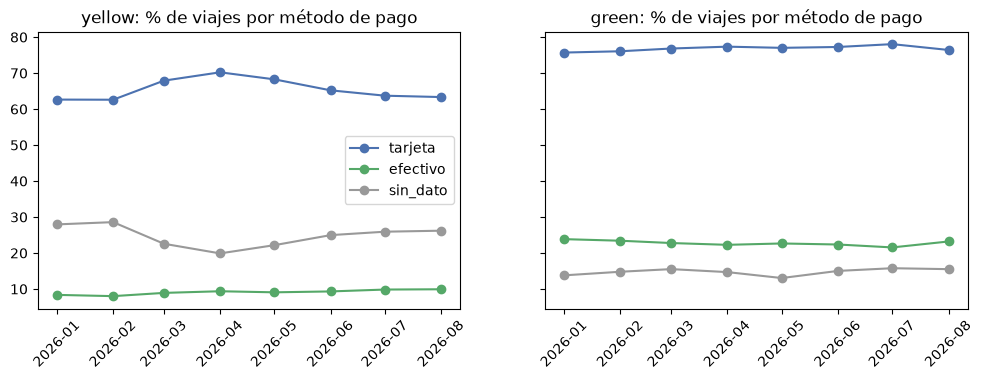

In [14]:
df = run("metodo_pago_por_mes")
fig, axes = plt.subplots(1, 2, figsize=(12, 3.6), sharey=True)
for ax, (taxi, d) in zip(axes, df.groupby("taxi_type", sort=False)):
    for col, c in (("pct_tarjeta", "#4c72b0"), ("pct_efectivo", "#55a868"), ("pct_sin_dato", "#999999")):
        ax.plot(d.mes, d[col], marker="o", label=col.replace("pct_", ""), color=c)
    ax.set_title(f"{taxi}: % de viajes por método de pago"); ax.tick_params(axis="x", rotation=45)
axes[0].legend()
guardar(fig, "04_metodo_pago_por_mes")

### P8. Propinas

In [15]:
run("propinas")

,taxi_type,viajes_tarjeta,pct_con_propina,propina_prom,propina_pct_mediana,propina_pct_prom_si_deja
0,green,211691,91.4,3.80,23.5,25.1
1,yellow,18770330,91.2,4.26,26.4,27.6


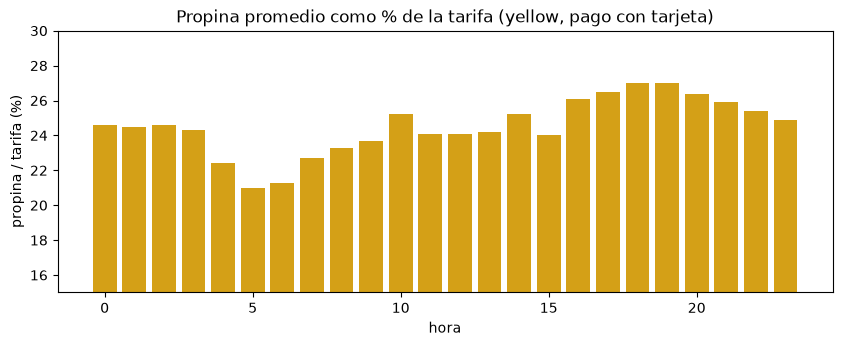

In [16]:
df = run("propina_por_hora")
fig, ax = plt.subplots(figsize=(10, 3.4))
ax.bar(df.hora, df.propina_pct_prom, color=COLOR["yellow"])
ax.set_ylim(15, 30); ax.set_xlabel("hora"); ax.set_ylabel("propina / tarifa (%)")
ax.set_title("Propina promedio como % de la tarifa (yellow, pago con tarjeta)")
guardar(fig, "04_propina_por_hora")

### P9. Recargos (congestión, zona CBD, aeropuerto)

In [17]:
run("recargos")

,taxi_type,pct_paga_cbd,pct_paga_congestion,pct_paga_aeropuerto,total_prom,tarifa_prom,pct_total_es_tarifa
0,green,8.5,33.2,NaN,25.43,16.80,66.0
1,yellow,72.4,90.3,8.7,30.19,21.23,66.6


## Valores atípicos e inconsistencias
### P10

In [18]:
run("velocidades_imposibles")

,taxi_type,mas_de_80mph,menos_de_1min,viajes,pct_mas_80mph
0,green,1087,3487,323096,0.336
1,yellow,7210,87686,28596404,0.025


In [19]:
run("atipicos_iqr_tarifa_por_milla")

,taxi_type,q1,q3,limite_superior,atipicos_altos,atipicos_bajos,pct_atipicos
0,yellow,5.64,9.52,15.34,1187947,0,4.35
1,green,5.28,8.00,12.08,10088,29037,12.50


In [20]:
run("registros_invalidos_por_mes")

,periodo,taxi_type,registros,pct_total_negativo,pct_distancia_cero,pct_duracion_invalida
0,202601,yellow,3724889,1.07,3.38,1.21
1,202602,yellow,3399866,0.80,3.63,1.19
2,202603,yellow,3952451,0.54,3.07,1.24
3,202604,yellow,3831240,0.39,2.44,1.29
4,202605,yellow,4090836,0.36,2.76,1.27
5,202606,yellow,3837248,0.37,3.34,1.30
6,202607,yellow,3530109,0.42,3.64,1.20
7,202608,yellow,3336716,0.43,3.57,1.29
8,202601,green,40272,0.30,3.20,0.07
9,202602,green,37373,0.29,3.71,0.07


In [21]:
run("invalidos_por_proveedor")

,taxi_type,vendor_id,registros,pct_duracion_invalida,pct_distancia_cero,pct_sin_dato_pago
0,yellow,1,5467071,0.08,1.65,16.38
1,yellow,2,23809774,0.00,3.59,28.40
2,yellow,6,59390,0.01,0.00,100.00
3,yellow,7,367120,100.00,1.84,0.00
4,green,1,28696,0.30,5.90,1.84
5,green,2,273571,0.05,3.84,4.90
6,green,6,34847,0.01,0.00,100.00


### P11. Despacho por aplicación (`request_source`, desde junio 2026)

,taxi_type,request_source,interpretacion,viajes,pct
0,yellow,NULL,NULL: sin app (probable parada en calle),7647917,74.34
1,yellow,HV0003,App Uber (licencia HVFHS),2092343,20.34
2,yellow,A,Codigo A (no documentado por la TLC),363662,3.54
3,yellow,HV0005,App Lyft (licencia HVFHS),162313,1.58
4,yellow,EH0004,E-hail (base EH0004),19594,0.19
5,yellow,CC,Codigo CC (no documentado por la TLC),1516,0.01
6,yellow,EH0010,E-hail (base EH0010),1,0.00
7,green,NULL,NULL: sin app (probable parada en calle),101977,84.59
8,green,A,Codigo A (no documentado por la TLC),17558,14.56
9,green,HV0005,App Lyft (licencia HVFHS),1020,0.85


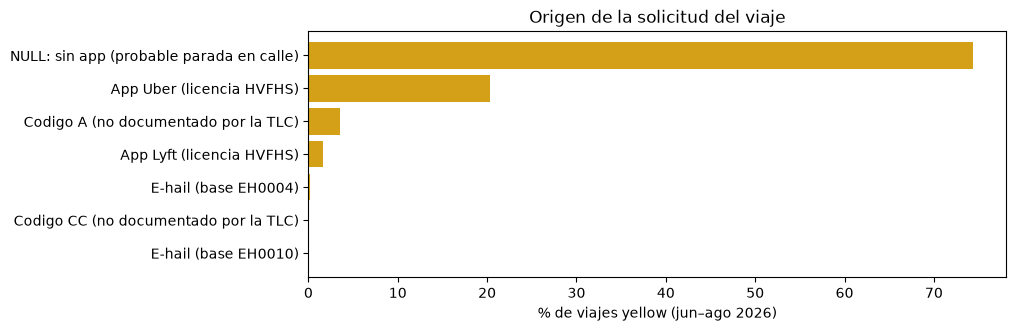

In [22]:
df = run("despacho_por_aplicacion"); display(df)
d = df[df.taxi_type == "yellow"]
fig, ax = plt.subplots(figsize=(9, 3.2))
ax.barh(d.interpretacion, d.pct, color=COLOR["yellow"]); ax.invert_yaxis()
ax.set_xlabel("% de viajes yellow (jun–ago 2026)"); ax.set_title("Origen de la solicitud del viaje")
guardar(fig, "04_request_source")